## Task 4a

Epoch 1/300


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


917/917 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9358 - loss: 0.2553 - val_accuracy: 0.9473 - val_loss: 0.1846
Epoch 2/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9477 - loss: 0.1837 - val_accuracy: 0.9475 - val_loss: 0.1826
Epoch 3/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9484 - loss: 0.1787 - val_accuracy: 0.9484 - val_loss: 0.1821
Epoch 4/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9476 - loss: 0.1817 - val_accuracy: 0.9476 - val_loss: 0.1812
Epoch 5/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9467 - loss: 0.1821 - val_accuracy: 0.9477 - val_loss: 0.1806
Epoch 6/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9469 - loss: 0.1819 - val_accuracy: 0.9475 - val_loss: 0.1815
Epoch 7/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9466 - loss: 0.1807 - val_accuracy: 0.9477 - val_loss: 0.1797
Epoch 8/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9476 - loss: 0.1785 - val_accuracy: 0.94

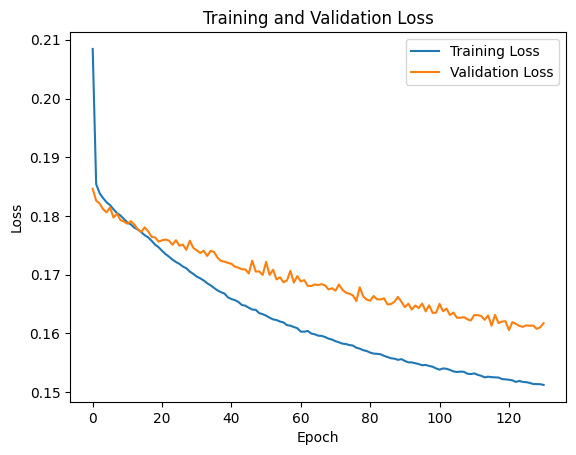

982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tuned Test Accuracy: 94.90%
Confusion Matrix:
 [[29544    70]
 [ 1531   270]]
Tuned ROC AUC: 0.8304


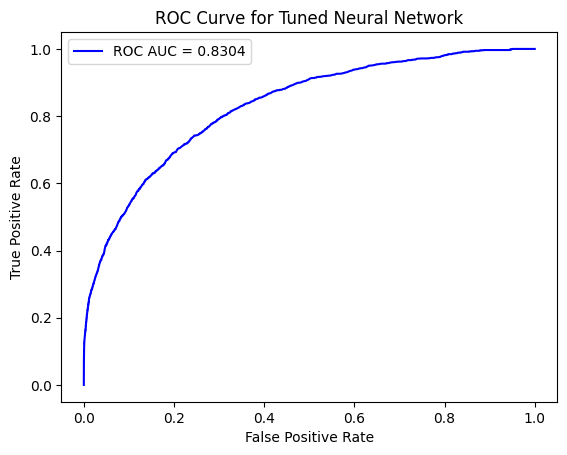

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess your dataset
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Log transformation for Amount and AnnualIncome
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
scaler = StandardScaler()
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = scaler.fit_transform(combined_data[numeric_cols])

# One-hot encoding for categorical variables
categorical_cols = ['LoyaltyTier', 'Region', 'PreferredPaymentMethod', 'PaymentMethod', 'CouponUsed', 
                    'IsEventDay', 'DayOfWeek', 'TimeOfDayCategory']
combined_data = pd.get_dummies(combined_data, columns=categorical_cols, drop_first=True)

# Select features and target variable
X = combined_data[['Age', 'LogAmount', 'LogAnnualIncome', 'AvgSpendPerVisit', 'BasketSize', 
                   'CustomerTenure', 'DaysSinceLastTransaction', 'FamilySize', 'ShoppingFrequency'] +
                   [col for col in combined_data.columns if col.startswith(tuple(categorical_cols))]]
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Enable mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define the neural network model using Keras
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(15, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fit the model with early stopping
history = model.fit(X_train, y_train, epochs=300, batch_size=64, validation_split=0.2, 
                    verbose=1, callbacks=[early_stopping])

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Predict on test data
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Tuned Test Accuracy: {test_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)
print(f"Tuned ROC AUC: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, color='blue', label=f'ROC AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Neural Network')
plt.legend()
plt.show()


## Task 4 c

Epoch 1/300


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


917/917 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5212 - loss: 0.6618 - val_accuracy: 0.9470 - val_loss: 0.1988
Epoch 2/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9477 - loss: 0.1928 - val_accuracy: 0.9470 - val_loss: 0.1910
Epoch 3/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9465 - loss: 0.1899 - val_accuracy: 0.9470 - val_loss: 0.1869
Epoch 4/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9442 - loss: 0.1927 - val_accuracy: 0.9470 - val_loss: 0.1847
Epoch 5/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9458 - loss: 0.1859 - val_accuracy: 0.9471 - val_loss: 0.1835
Epoch 6/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9447 - loss: 0.1880 - val_accuracy: 0.9470 - val_loss: 0.1830
Epoch 7/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9470 - loss: 0.1814 - val_accuracy: 0.9473 - val_loss: 0.1827
Epoch 8/300
917/917 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9460 - loss: 0.1841 - val_accuracy: 0.9473

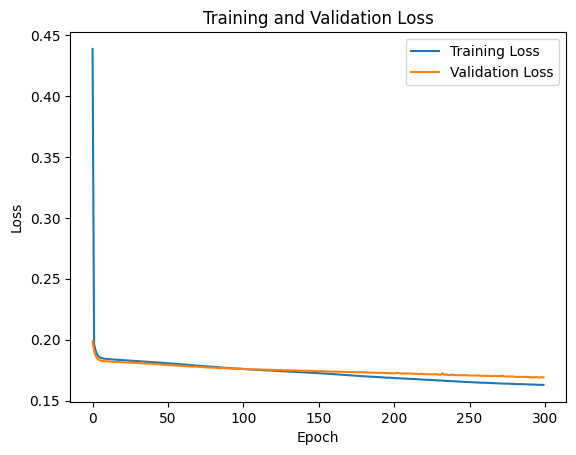

982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tuned Test Accuracy: 94.56%
Confusion Matrix:
 [[29573    41]
 [ 1667   134]]
Tuned ROC AUC: 0.8040


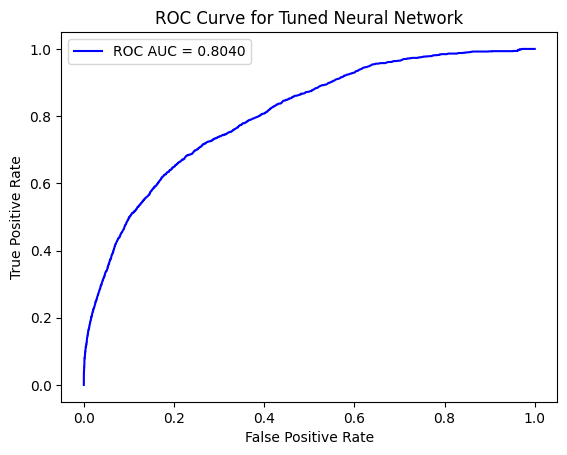

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess your dataset
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Log transformation for Amount and AnnualIncome
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
scaler = StandardScaler()
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = scaler.fit_transform(combined_data[numeric_cols])

# One-hot encoding for categorical variables
categorical_cols = ['LoyaltyTier', 'Region', 'PreferredPaymentMethod', 'PaymentMethod', 'CouponUsed', 
                    'IsEventDay', 'DayOfWeek', 'TimeOfDayCategory']
combined_data = pd.get_dummies(combined_data, columns=categorical_cols, drop_first=True)

# Select features and target variable
X = combined_data[['Age', 'LogAmount', 'LogAnnualIncome', 'AvgSpendPerVisit', 'BasketSize', 
                   'CustomerTenure', 'DaysSinceLastTransaction', 'FamilySize', 'ShoppingFrequency'] +
                   [col for col in combined_data.columns if col.startswith(tuple(categorical_cols))]]
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Enable mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define the neural network model using Keras
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(15, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fit the model with early stopping
history = model.fit(X_train, y_train, epochs=300, batch_size=64, validation_split=0.2, 
                    verbose=1, callbacks=[early_stopping])

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Predict on test data
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Tuned Test Accuracy: {test_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)
print(f"Tuned ROC AUC: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, color='blue', label=f'ROC AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Neural Network')
plt.legend()
plt.show()


Epoch 1/300


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


459/459 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8862 - loss: 0.2677 - val_accuracy: 0.9471 - val_loss: 0.1832
Epoch 2/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9451 - loss: 0.1900 - val_accuracy: 0.9473 - val_loss: 0.1841
Epoch 3/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9470 - loss: 0.1813 - val_accuracy: 0.9481 - val_loss: 0.1816
Epoch 4/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9462 - loss: 0.1859 - val_accuracy: 0.9480 - val_loss: 0.1815
Epoch 5/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9473 - loss: 0.1804 - val_accuracy: 0.9482 - val_loss: 0.1812
Epoch 6/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9492 - loss: 0.1769 - val_accuracy: 0.9482 - val_loss: 0.1817
Epoch 7/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9477 - loss: 0.1793 - val_accuracy: 0.9483 - val_loss: 0.1795
Epoch 8/300
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9477 - loss: 0.1811 - val_accuracy

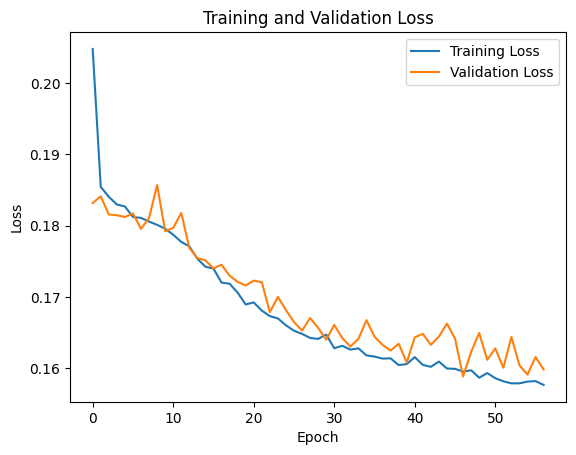

982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tuned Test Accuracy: 94.68%
Confusion Matrix:
 [[29556    58]
 [ 1614   187]]
Tuned ROC AUC: 0.8309


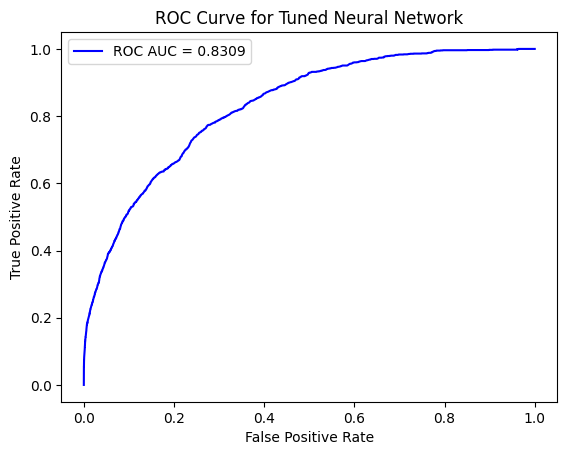

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess your dataset
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Log transformation for Amount and AnnualIncome
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
scaler = StandardScaler()
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = scaler.fit_transform(combined_data[numeric_cols])

# One-hot encoding for categorical variables
categorical_cols = ['LoyaltyTier', 'Region', 'PreferredPaymentMethod', 'PaymentMethod', 'CouponUsed', 
                    'IsEventDay', 'DayOfWeek', 'TimeOfDayCategory']
combined_data = pd.get_dummies(combined_data, columns=categorical_cols, drop_first=True)

# Select features and target variable
X = combined_data[['Age', 'LogAmount', 'LogAnnualIncome', 'AvgSpendPerVisit', 'BasketSize', 
                   'CustomerTenure', 'DaysSinceLastTransaction', 'FamilySize', 'ShoppingFrequency'] +
                   [col for col in combined_data.columns if col.startswith(tuple(categorical_cols))]]
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Enable mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define the neural network model using Keras
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(15, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fit the model with early stopping
history = model.fit(X_train, y_train, epochs=300, batch_size=128, validation_split=0.2, 
                    verbose=1, callbacks=[early_stopping])

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Predict on test data
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Tuned Test Accuracy: {test_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)
print(f"Tuned ROC AUC: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, color='blue', label=f'ROC AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Neural Network')
plt.legend()
plt.show()


Epoch 1/300


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9429 - loss: 0.2314 - val_accuracy: 0.9470 - val_loss: 0.1844
Epoch 2/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9445 - loss: 0.1892 - val_accuracy: 0.9470 - val_loss: 0.1873
Epoch 3/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9461 - loss: 0.1852 - val_accuracy: 0.9471 - val_loss: 0.1813
Epoch 4/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9462 - loss: 0.1829 - val_accuracy: 0.9477 - val_loss: 0.1809
Epoch 5/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9485 - loss: 0.1768 - val_accuracy: 0.9481 - val_loss: 0.1800
Epoch 6/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9472 - loss: 0.1793 - val_accuracy: 0.9479 - val_loss: 0.1797
Epoch 7/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9476 - loss: 0.1788 - val_accuracy: 0.9478 - val_loss: 0.1792
Epoch 8/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9473 - loss: 0.1778 - val_accuracy

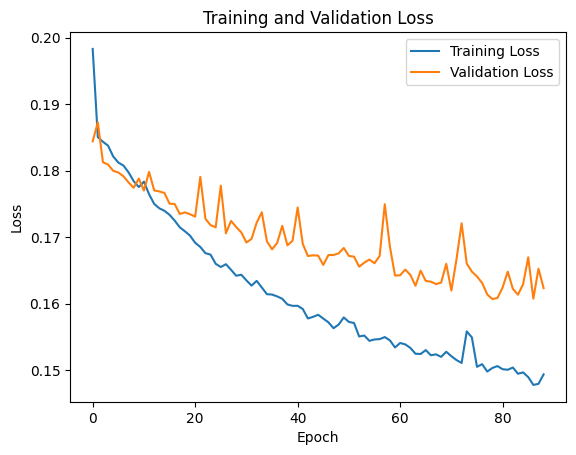

982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tuned Test Accuracy: 94.71%
Confusion Matrix:
 [[29500   114]
 [ 1547   254]]
Tuned ROC AUC: 0.8522


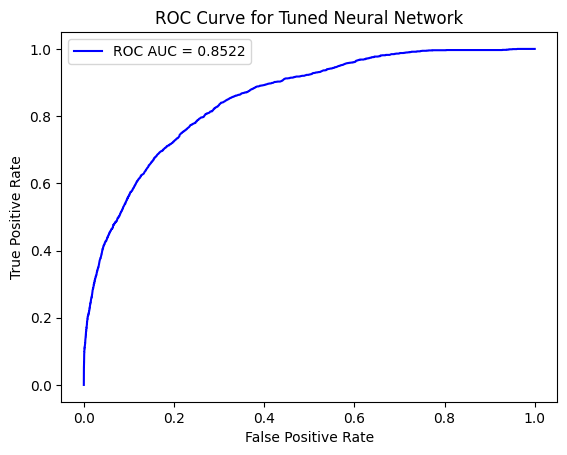

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess your dataset
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Log transformation for Amount and AnnualIncome
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
scaler = StandardScaler()
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = scaler.fit_transform(combined_data[numeric_cols])

# One-hot encoding for categorical variables
categorical_cols = ['LoyaltyTier', 'Region', 'PreferredPaymentMethod', 'PaymentMethod', 'CouponUsed', 
                    'IsEventDay', 'DayOfWeek', 'TimeOfDayCategory']
combined_data = pd.get_dummies(combined_data, columns=categorical_cols, drop_first=True)

# Select features and target variable
X = combined_data[['Age', 'LogAmount', 'LogAnnualIncome', 'AvgSpendPerVisit', 'BasketSize', 
                   'CustomerTenure', 'DaysSinceLastTransaction', 'FamilySize', 'ShoppingFrequency'] +
                   [col for col in combined_data.columns if col.startswith(tuple(categorical_cols))]]
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Enable mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define the neural network model using Keras
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(15, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fit the model with early stopping
history = model.fit(X_train, y_train, epochs=300, batch_size=256, validation_split=0.2, 
                    verbose=1, callbacks=[early_stopping])

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Predict on test data
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Tuned Test Accuracy: {test_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)
print(f"Tuned ROC AUC: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, color='blue', label=f'ROC AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Neural Network')
plt.legend()
plt.show()


Epoch 1/300


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9463 - loss: 0.2023 - val_accuracy: 0.9477 - val_loss: 0.1819
Epoch 2/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9464 - loss: 0.1845 - val_accuracy: 0.9480 - val_loss: 0.1808
Epoch 3/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9462 - loss: 0.1850 - val_accuracy: 0.9481 - val_loss: 0.1839
Epoch 4/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9465 - loss: 0.1822 - val_accuracy: 0.9482 - val_loss: 0.1803
Epoch 5/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9472 - loss: 0.1795 - val_accuracy: 0.9482 - val_loss: 0.1770
Epoch 6/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9471 - loss: 0.1772 - val_accuracy: 0.9484 - val_loss: 0.1770
Epoch 7/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9474 - loss: 0.1781 - val_accuracy: 0.9490 - val_loss: 0.1787
Epoch 8/300
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9465 - loss: 0.1768 - val_accuracy

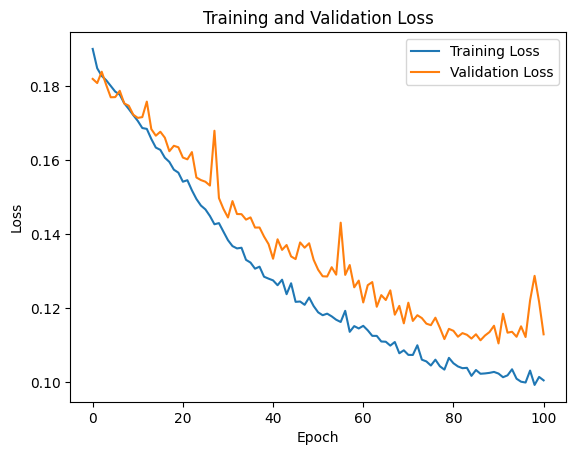

982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Tuned Test Accuracy: 96.05%
Confusion Matrix:
 [[29455   159]
 [ 1083   718]]
Tuned ROC AUC: 0.9303


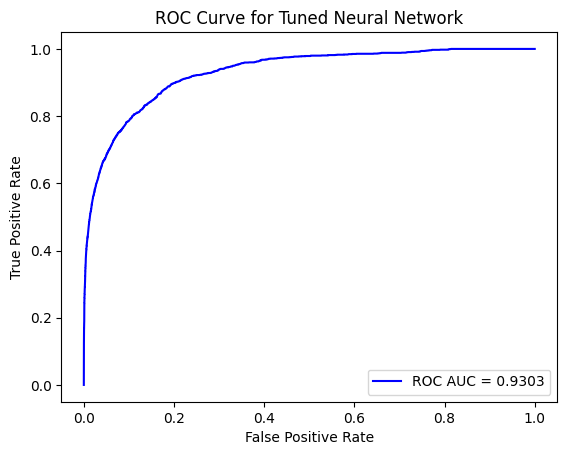

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess your dataset
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Log transformation for Amount and AnnualIncome
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
scaler = StandardScaler()
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = scaler.fit_transform(combined_data[numeric_cols])

# One-hot encoding for categorical variables
categorical_cols = ['LoyaltyTier', 'Region', 'PreferredPaymentMethod', 'PaymentMethod', 'CouponUsed', 
                    'IsEventDay', 'DayOfWeek', 'TimeOfDayCategory']
combined_data = pd.get_dummies(combined_data, columns=categorical_cols, drop_first=True)

# Select features and target variable
X = combined_data[['Age', 'LogAmount', 'LogAnnualIncome', 'AvgSpendPerVisit', 'BasketSize', 
                   'CustomerTenure', 'DaysSinceLastTransaction', 'FamilySize', 'ShoppingFrequency'] +
                   [col for col in combined_data.columns if col.startswith(tuple(categorical_cols))]]
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Enable mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define the neural network model using Keras
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fit the model with early stopping
history = model.fit(X_train, y_train, epochs=300, batch_size=256, validation_split=0.2, 
                    verbose=1, callbacks=[early_stopping])

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Predict on test data
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Tuned Test Accuracy: {test_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)
print(f"Tuned ROC AUC: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, color='blue', label=f'ROC AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Neural Network')
plt.legend()
plt.show()


## Task 5a

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3973, number of negative: 69326
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.198034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10971
[LightGBM] [Info] Number of data points in the train set: 73299, number of used features: 3415
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.364308 -> initscore=-0.556713
[LightGBM] [Info] Start training from score -0.556713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


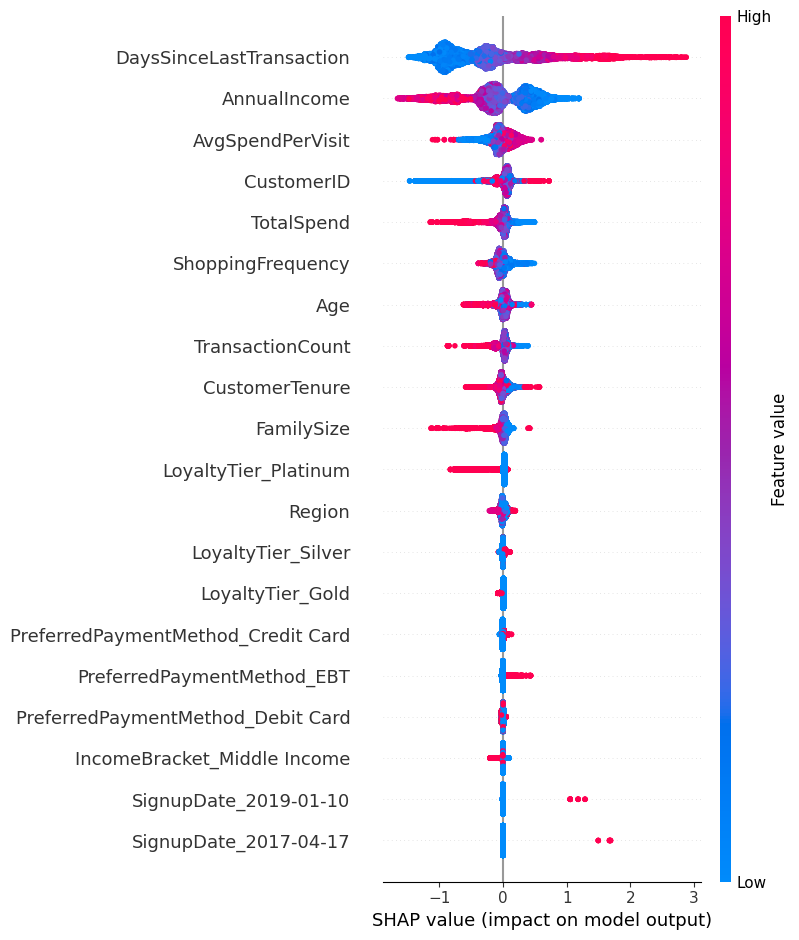

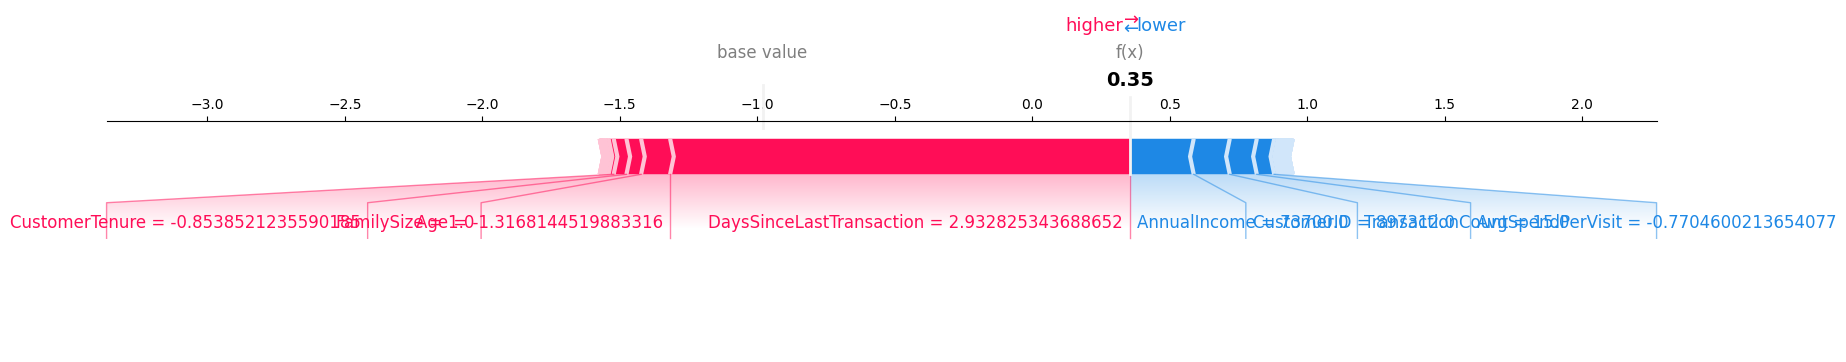

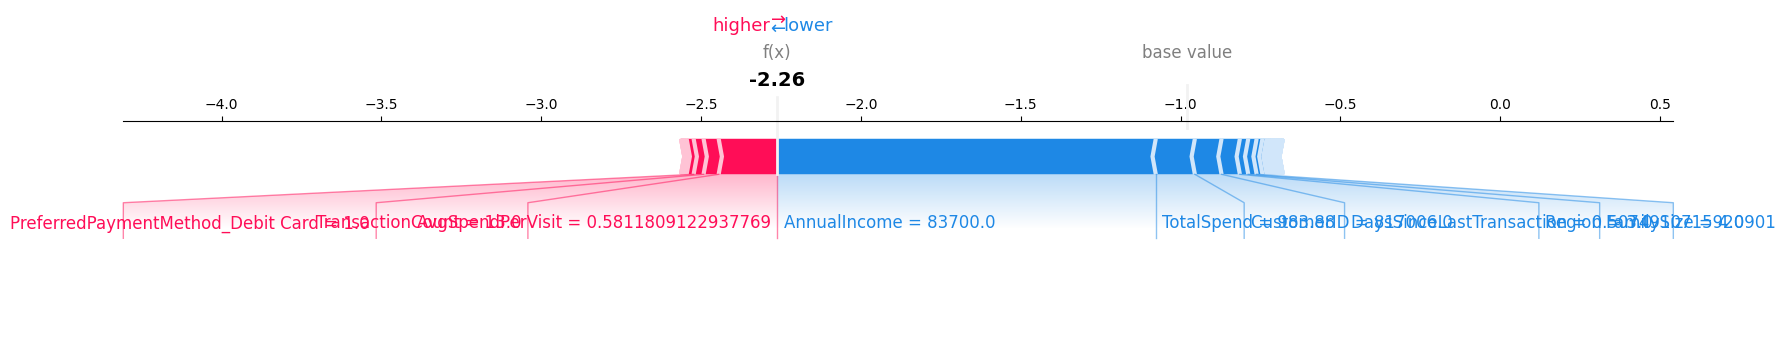

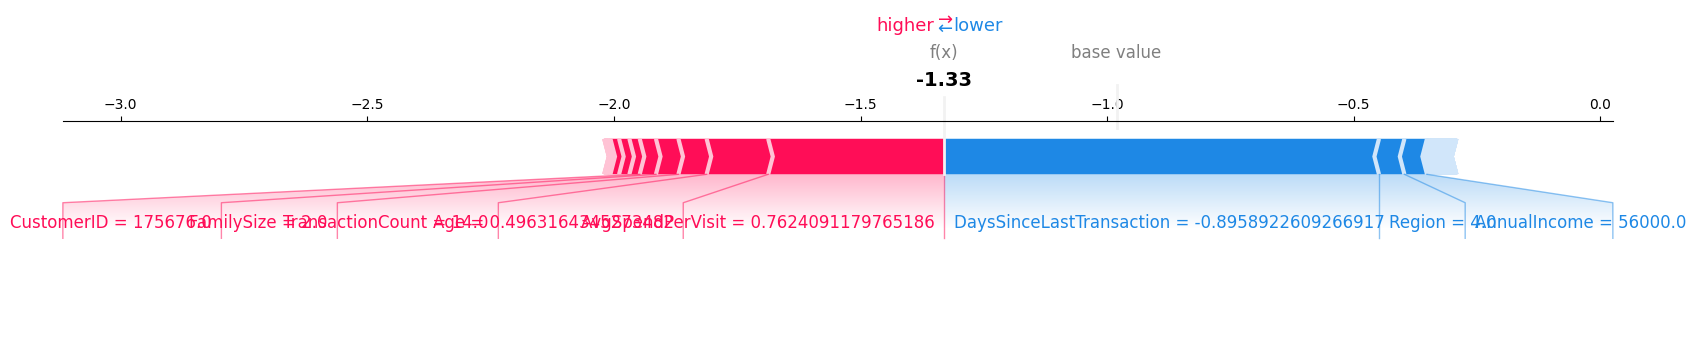

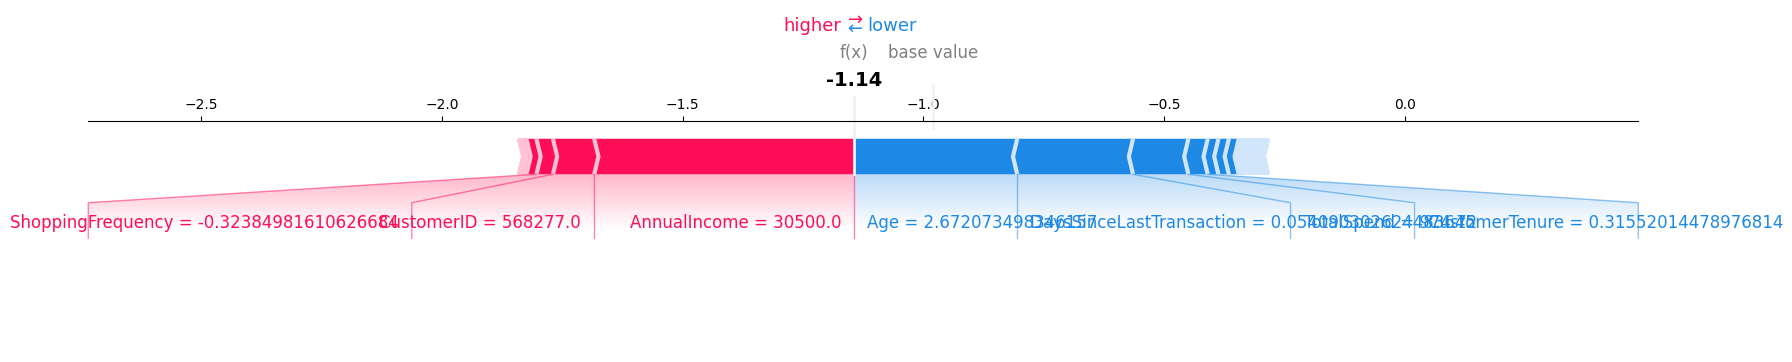

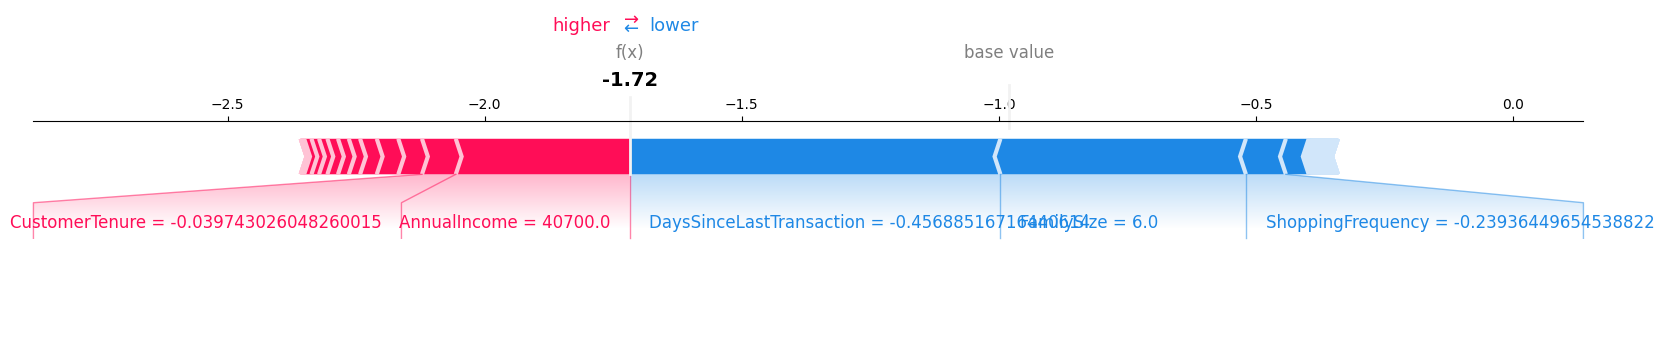

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

# Load Data
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Feature Engineering and Preprocessing
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = StandardScaler().fit_transform(combined_data[numeric_cols])

# Ensure all categorical columns are converted to numerical
for col in combined_data.columns:
    if combined_data[col].dtype == 'object':  # If column is of object type (string)
        combined_data[col] = combined_data[col].astype('category')  # Convert to categorical type
        combined_data = pd.get_dummies(combined_data, columns=[col], drop_first=True)  # Apply one-hot encoding

# Define features (X) and target (y)
X = combined_data.drop(columns=['Churn'])
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Configure LightGBM with class weighting to increase the importance of churned customers
lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt', 
    data_sample_strategy='goss',  # To suppress the "boosting=goss" warning
    max_depth=5, 
    n_estimators=100, 
    learning_rate=0.1,
    class_weight={0: 1, 1: 10},  # Assign higher weight to class 1 (churned customers)
    random_state=42
)

# Fit the LightGBM model
lgb_model.fit(X_train, y_train)

# Predict on test set using default threshold of 0.5
test_pred_lgb = lgb_model.predict(X_test)

# Classification Report with default threshold
print("Classification Report (default threshold 0.5):")
print(classification_report(y_test, test_pred_lgb))

# Calculate ROC AUC Score
y_pred_prob = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Adjust the probability threshold to improve recall for class 1
custom_threshold = 0.3
test_pred_custom = (y_pred_prob >= custom_threshold).astype(int)

# Classification Report with adjusted threshold
print(f"\nClassification Report (custom threshold {custom_threshold}):")
print(classification_report(y_test, test_pred_custom))

# Confusion Matrix for custom threshold
print("Confusion Matrix (custom threshold):")
print(confusion_matrix(y_test, test_pred_custom))


# SHAP Analysis to Interpret the Model
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Select the SHAP values for the positive class if shap_values is a list
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use SHAP values for the positive class

# Summary plot for global feature importance
shap.summary_plot(shap_values, X_test)

# Adjusted Force plot for individual predictions
for i in range(5):  # Display the first 5 predictions for interpretation
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
        shap_values[i], 
        X_test.iloc[i, :],
        matplotlib=True
    )


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3179, number of negative: 55461
[LightGBM] [Info] Number of positive: 3179, number of negative: 55461
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.879780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9463
[LightGBM] [Info] Number of data points in the train set: 58640, number of used features: 2662
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.364351 -> initscore=-0.556528
[LightGBM] [Info] Start training from score -0.556528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.994040 seconds.
You can set `force_col_wise=true` to remove the

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


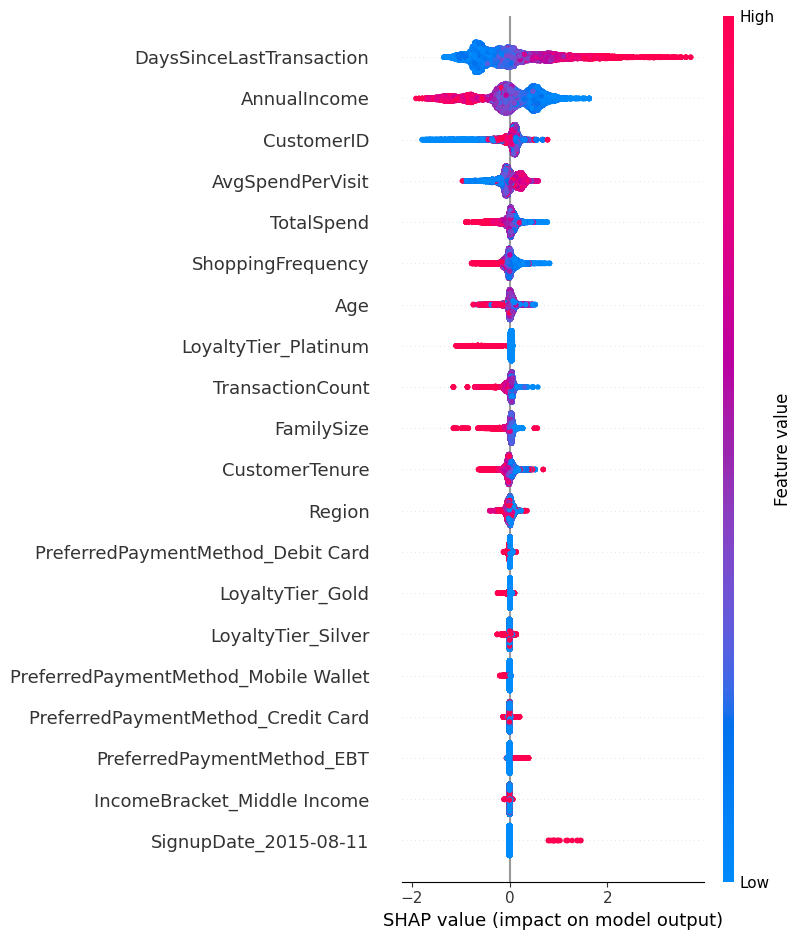

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

# Load Data
combined_data = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/combined_data.csv')

# Feature Engineering and Preprocessing
combined_data['LogAmount'] = np.log1p(combined_data['Amount'])
combined_data['LogAnnualIncome'] = np.log1p(combined_data['AnnualIncome'])

# Standardize numeric variables
numeric_cols = ['Age', 'AvgSpendPerVisit', 'BasketSize', 'CustomerTenure', 'DaysSinceLastTransaction', 'ShoppingFrequency']
combined_data[numeric_cols] = StandardScaler().fit_transform(combined_data[numeric_cols])

# Ensure all categorical columns are converted to numerical
for col in combined_data.columns:
    if combined_data[col].dtype == 'object':
        combined_data[col] = combined_data[col].astype('category')
        combined_data = pd.get_dummies(combined_data, columns=[col], drop_first=True)

# Define features (X) and target (y)
X = combined_data.drop(columns=['Churn'])
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Set up parameter grid for tuning
param_grid = {
    'num_leaves': [15, 31, 63],      # Controls complexity
    'max_depth': [3, 5, 7]           # Tree depth
}

# Initialize the LightGBM model
lgb_model = lgb.LGBMClassifier(boosting_type='gbdt', random_state=42, class_weight={0: 1, 1: 10}, n_estimators=100)

# Grid search with cross-validation to find the best parameters, with verbose output
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Extract the best model from grid search
best_lgb_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate the best model on test data
y_pred_prob_best = best_lgb_model.predict_proba(X_test)[:, 1]
roc_auc_best = roc_auc_score(y_test, y_pred_prob_best)
print(f"Best ROC AUC Score: {roc_auc_best:.4f}")

# Adjust threshold based on tuned model
custom_threshold = 0.3
test_pred_custom_best = (y_pred_prob_best >= custom_threshold).astype(int)

# Classification Report and Confusion Matrix with adjusted threshold
print("\nClassification Report (custom threshold with tuned model):")
print(classification_report(y_test, test_pred_custom_best))
print("Confusion Matrix (custom threshold with tuned model):")
print(confusion_matrix(y_test, test_pred_custom_best))

# SHAP Analysis with the tuned model
explainer = shap.TreeExplainer(best_lgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot for global feature importance with tuned model
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use SHAP values for the positive class
shap.summary_plot(shap_values, X_test)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


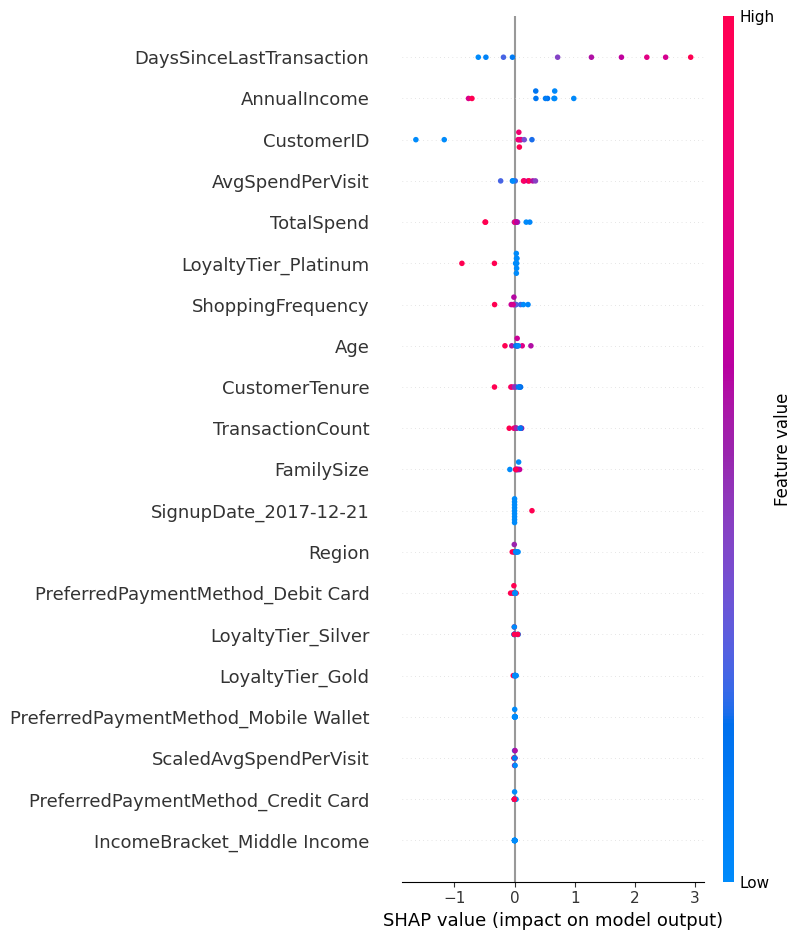

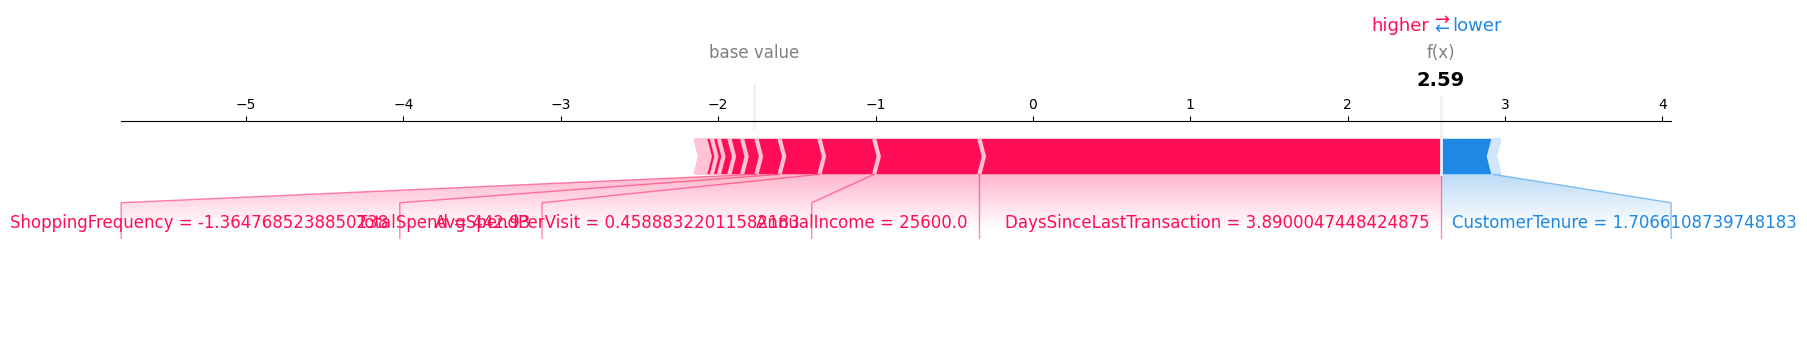

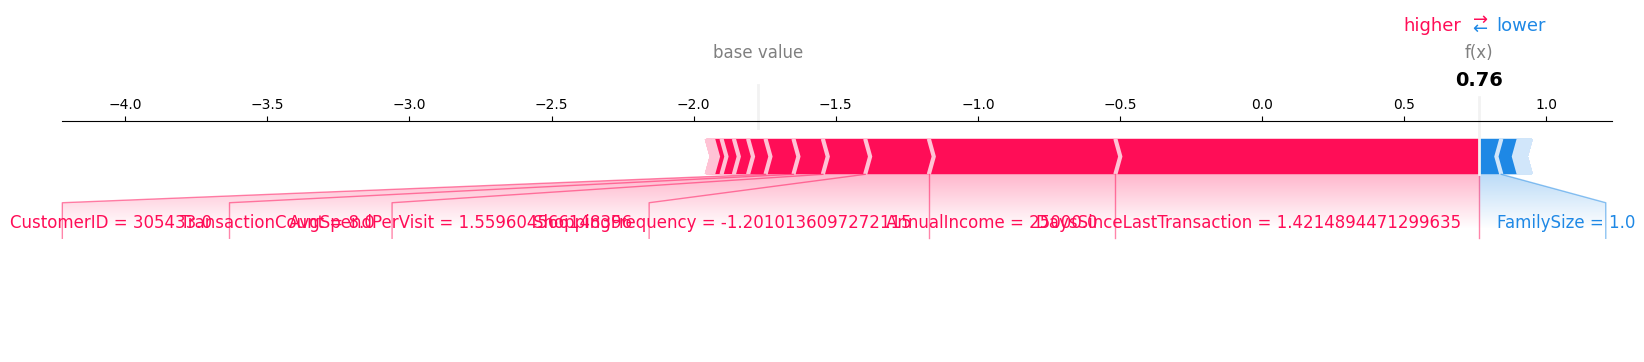

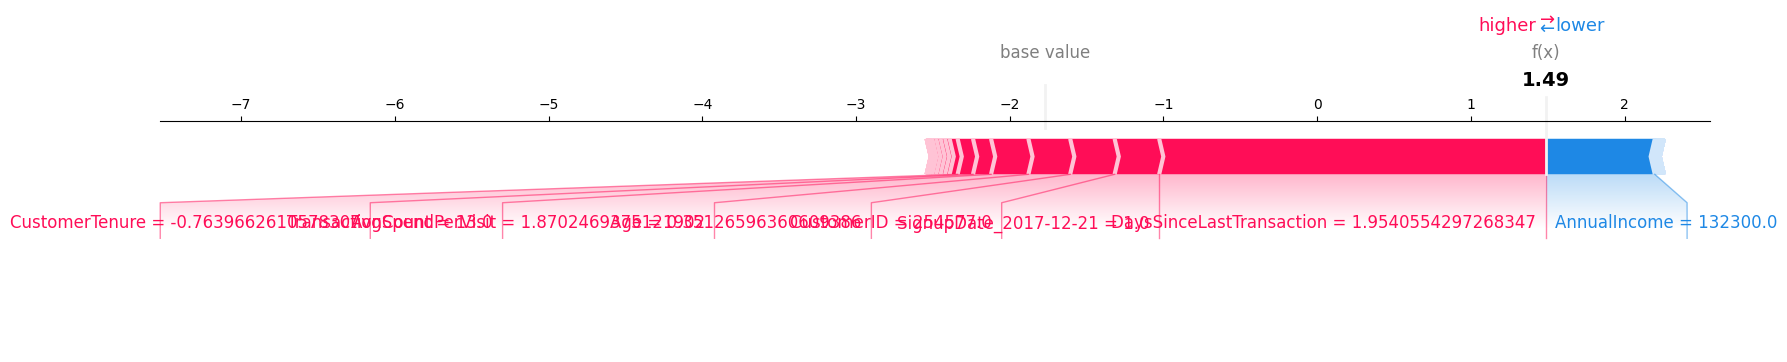

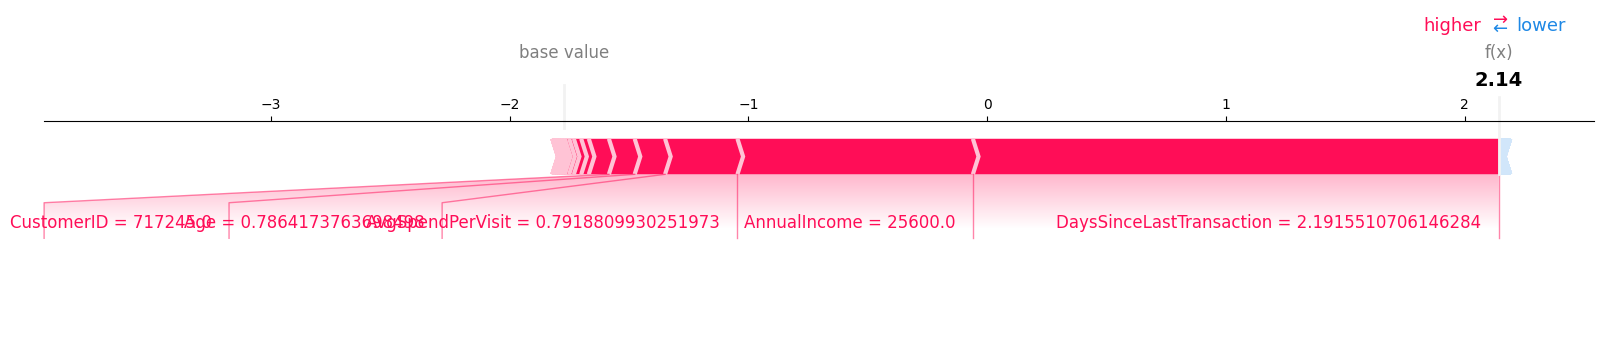

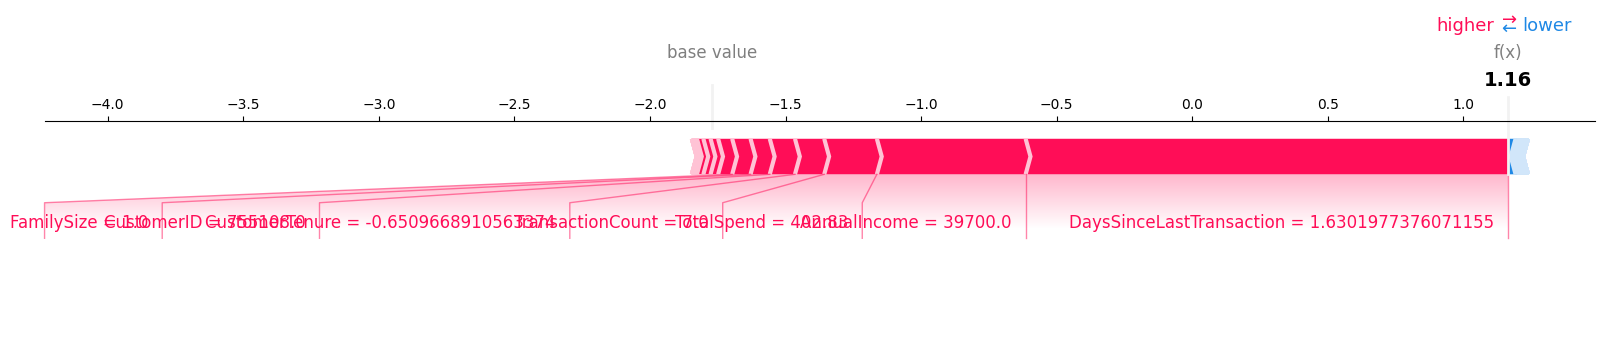

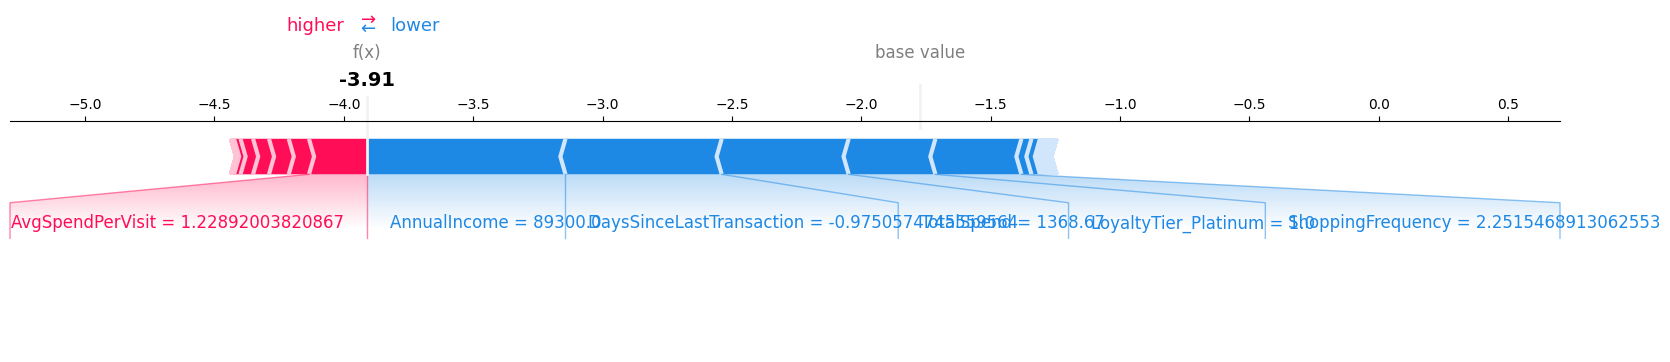

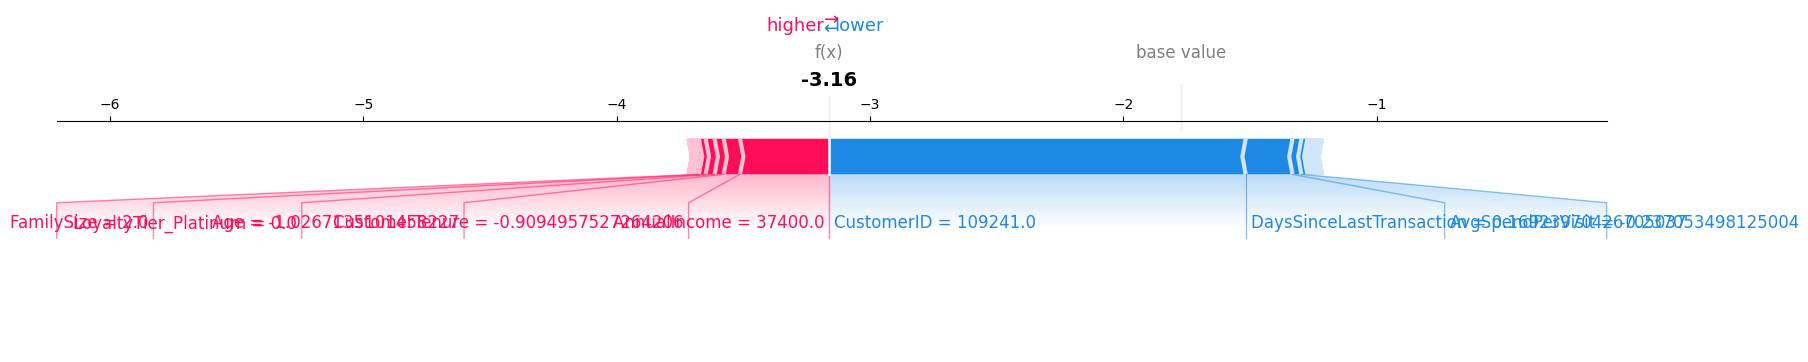

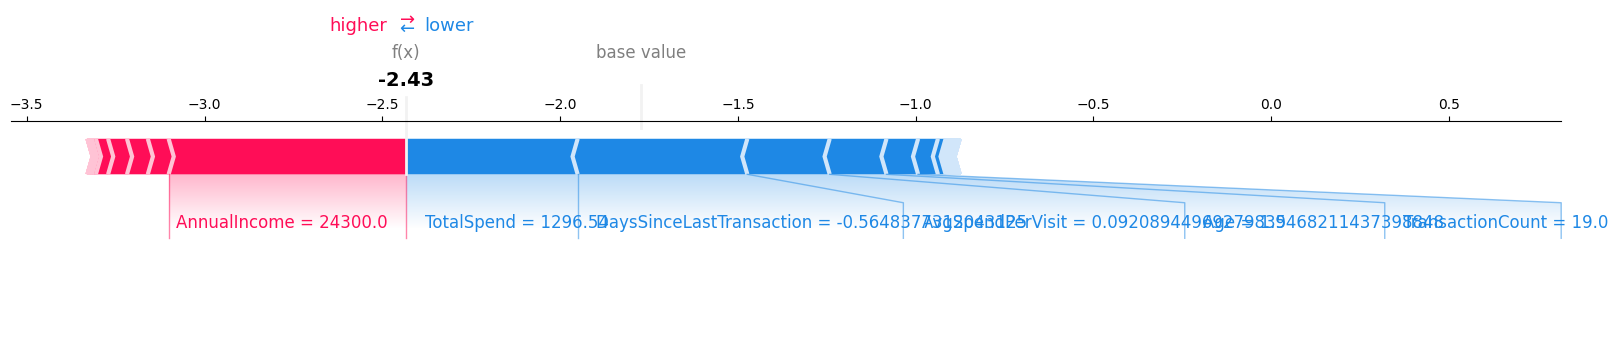

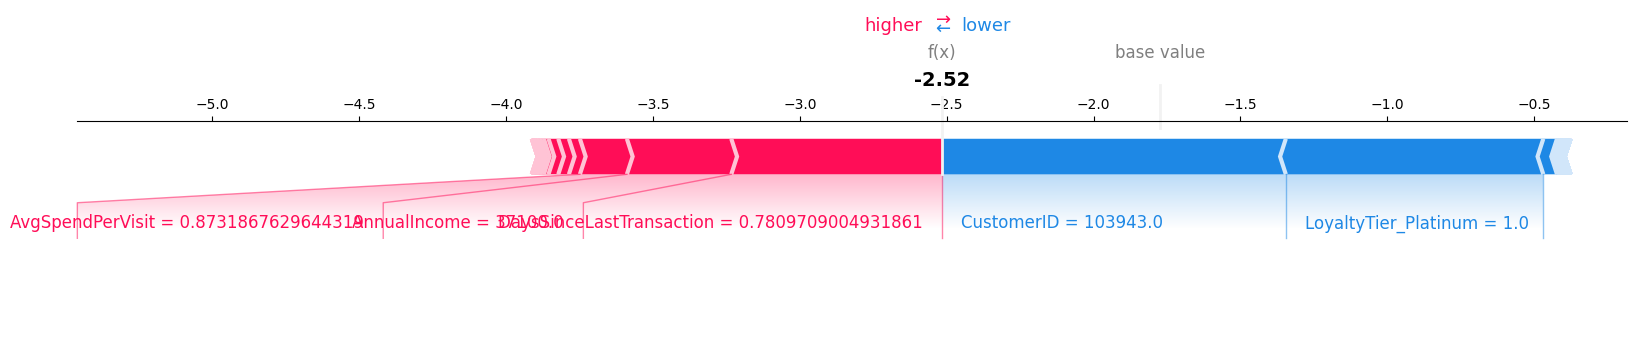

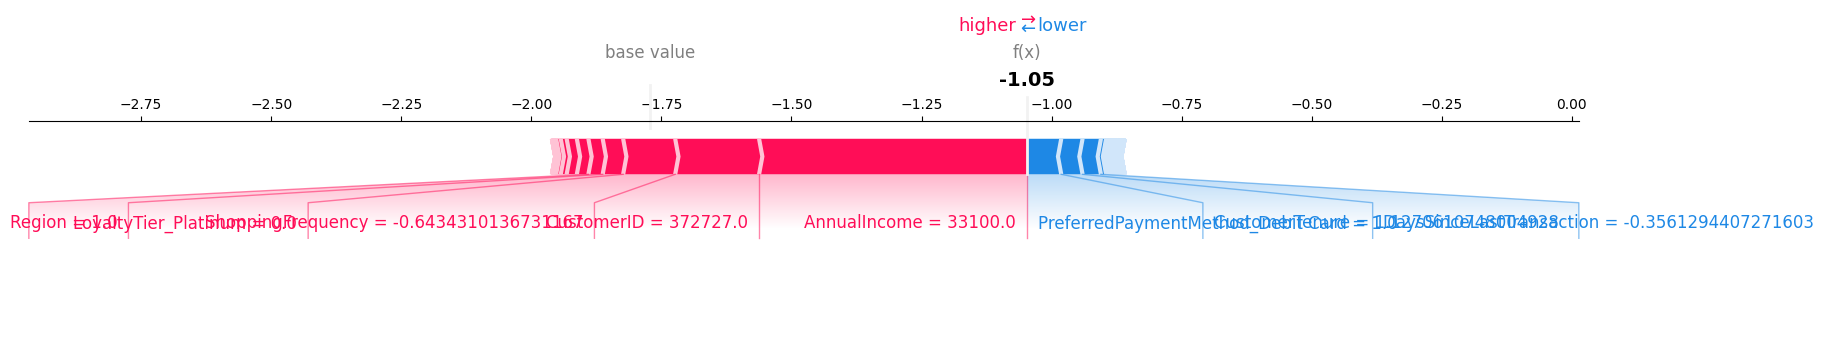

In [5]:
import shap

# Select 5 individuals who have churned and 5 who have not
churned_samples = X_test[y_test == 1].sample(5, random_state=42)
not_churned_samples = X_test[y_test == 0].sample(5, random_state=42)

# Combine these samples for SHAP analysis
selected_samples = pd.concat([churned_samples, not_churned_samples])

# SHAP Analysis for selected individuals
explainer = shap.TreeExplainer(best_lgb_model)
shap_values = explainer.shap_values(selected_samples)

# Interpret SHAP values - summary plot for selected samples
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use SHAP values for the positive class
shap.summary_plot(shap_values, selected_samples)

# Display SHAP force plot for each selected individual
for i in range(selected_samples.shape[0]):
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        shap_values[i],
        selected_samples.iloc[i, :],
        matplotlib=True
    )


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y) as in your initial setup
X = combined_data.drop(columns=['Churn'])
y = combined_data['Churn']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Hyperparameter tuning for the Random Forest model


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_rf_model = grid_search.best_estimator_

# Fit the best model
best_rf_model.fit(X_train, y_train)

# Evaluate accuracy on training and test sets
train_accuracy = accuracy_score(y_train, best_rf_model.predict(X_train))
test_accuracy = accuracy_score(y_test, best_rf_model.predict(X_test))

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Classification Report (Test):")
print(classification_report(y_test, best_rf_model.predict(X_test)))


Training Accuracy: 1.0
Test Accuracy: 0.9934107910233965
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     29614
           1       1.00      0.89      0.94      1801

    accuracy                           0.99     31415
   macro avg       1.00      0.94      0.97     31415
weighted avg       0.99      0.99      0.99     31415



In [49]:
import shap
import pandas as pd

# Initialize SHAP Kernel Explainer with a sample of X_train
kernel_explainer = shap.KernelExplainer(best_rf_model.predict_proba, X_train.sample(100, random_state=42))

# Calculate SHAP values for the sample customers
shap_values = kernel_explainer.shap_values(sample_customers)

# Extract SHAP values for the positive class (churned)
shap_values_churn = shap_values[1]  # Selecting the SHAP values for the churned class

# Create a DataFrame for the SHAP values
shap_df = pd.DataFrame(shap_values_churn, columns=sample_customers.columns)
shap_df['Customer'] = ['Churned']*5 + ['Not Churned']*5
shap_df = shap_df.set_index('Customer')

# Show the SHAP values DataFrame
shap_df


,CustomerID,Age,Region,FamilySize,AnnualIncome,TransactionCount,DaysSinceLastTransaction,CustomerTenure,TransactionID,TimeOfDay,...,PaymentMethod_Debit Card,PaymentMethod_EBT,PaymentMethod_Mobile Wallet,PaymentMethod_Other,PaymentMethod_WIC,IncomeBracket_Low Income,IncomeBracket_Middle Income,TimeOfDayCategory_Evening,TimeOfDayCategory_Morning,TimeOfDayCategory_Night
Customer,,,,,,,,,,,,,,,,,,,,,
Churned,0.025399,0.002057,0.000000,0.003927,0.038217,0.016022,0.145513,0.019368,0.002048,-0.006316,...,0.003010,0.000000,0.000000,0.0,0.000000,0.018615,0.000000,-0.006282,0.000000,0.00000
Churned,0.001975,0.009563,0.003971,0.011093,0.029148,0.007701,0.069365,0.000000,-0.006973,-0.006411,...,0.000000,0.000000,0.003908,0.0,0.000000,0.030163,0.000000,0.000000,0.000000,0.00124
Churned,0.004098,0.005434,0.004241,0.004003,0.011090,0.004684,0.092629,0.007954,0.000000,0.001378,...,0.000000,0.000000,0.000000,0.0,0.000000,0.005898,0.000000,-0.007673,0.000000,-0.00660
Churned,0.011955,0.010084,0.002938,0.004664,0.041246,0.009792,0.145578,0.000000,0.000000,0.003517,...,0.000000,0.000000,0.000000,0.0,0.000000,0.036688,0.000000,0.000000,0.000000,0.00000
Churned,0.000719,0.007535,0.003086,0.007280,0.038999,0.029939,0.081293,0.002442,0.002813,-0.003553,...,0.000000,0.000000,-0.009756,0.0,0.000000,0.038475,0.002106,0.000000,0.000000,0.00000
Not Churned,0.000000,0.000000,0.000000,0.000000,-0.005832,-0.001377,-0.003682,0.003811,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,-0.001246,-0.001006,0.000000,0.000000,0.00000
Not Churned,0.000000,0.000000,-0.001553,0.000000,0.001302,0.000000,0.000000,-0.001080,0.000000,0.000000,...,0.001141,0.000000,0.000000,0.0,0.000000,0.001298,0.000000,0.000000,0.000000,0.00000
Not Churned,-0.000671,0.000000,0.000000,0.000000,0.005282,0.000000,-0.007994,0.000000,0.000000,0.000000,...,0.000000,-0.000525,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Not Churned,0.002027,-0.000209,-0.000383,0.000000,0.003501,-0.002173,-0.001473,-0.001677,-0.000891,0.000000,...,0.000000,0.000000,0.000000,0.0,-0.000193,-0.002185,-0.001469,-0.000655,0.000000,0.00000


In [11]:
# If shap_values is 3D, select the SHAP values for the positive (churn) class
# by taking the last dimension's values for the churn class (index 1)
shap_values = shap_values[1] if isinstance(shap_values, list) else shap_values
shap_values = shap_values[:, :, 1]  # Select the churn class (second index)

# Convert SHAP values into a DataFrame
shap_df = pd.DataFrame(shap_values, columns=sample_customers.columns)
shap_df['Customer'] = ['Churned']*5 + ['Not Churned']*5
shap_df = shap_df.set_index('Customer')

# Display the SHAP values DataFramed
shap_df


,CustomerID,Age,Region,FamilySize,AnnualIncome,TransactionCount,DaysSinceLastTransaction,CustomerTenure,TransactionID,TimeOfDay,...,PaymentMethod_Debit Card,PaymentMethod_EBT,PaymentMethod_Mobile Wallet,PaymentMethod_Other,PaymentMethod_WIC,IncomeBracket_Low Income,IncomeBracket_Middle Income,TimeOfDayCategory_Evening,TimeOfDayCategory_Morning,TimeOfDayCategory_Night
Customer,,,,,,,,,,,,,,,,,,,,,
Churned,0.025399,0.002057,0.000000,0.003927,0.038217,0.016022,0.145513,0.019368,0.002048,-0.006316,...,0.003010,0.000000,0.000000,0.0,0.000000,0.018615,0.000000,-0.006282,0.000000,0.00000
Churned,0.001975,0.009563,0.003971,0.011093,0.029148,0.007701,0.069365,0.000000,-0.006973,-0.006411,...,0.000000,0.000000,0.003908,0.0,0.000000,0.030163,0.000000,0.000000,0.000000,0.00124
Churned,0.004098,0.005434,0.004241,0.004003,0.011090,0.004684,0.092629,0.007954,0.000000,0.001378,...,0.000000,0.000000,0.000000,0.0,0.000000,0.005898,0.000000,-0.007673,0.000000,-0.00660
Churned,0.011955,0.010084,0.002938,0.004664,0.041246,0.009792,0.145578,0.000000,0.000000,0.003517,...,0.000000,0.000000,0.000000,0.0,0.000000,0.036688,0.000000,0.000000,0.000000,0.00000
Churned,0.000719,0.007535,0.003086,0.007280,0.038999,0.029939,0.081293,0.002442,0.002813,-0.003553,...,0.000000,0.000000,-0.009756,0.0,0.000000,0.038475,0.002106,0.000000,0.000000,0.00000
Not Churned,0.000000,0.000000,0.000000,0.000000,-0.005832,-0.001377,-0.003682,0.003811,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,-0.001246,-0.001006,0.000000,0.000000,0.00000
Not Churned,0.000000,0.000000,-0.001553,0.000000,0.001302,0.000000,0.000000,-0.001080,0.000000,0.000000,...,0.001141,0.000000,0.000000,0.0,0.000000,0.001298,0.000000,0.000000,0.000000,0.00000
Not Churned,-0.000671,0.000000,0.000000,0.000000,0.005282,0.000000,-0.007994,0.000000,0.000000,0.000000,...,0.000000,-0.000525,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Not Churned,0.002027,-0.000209,-0.000383,0.000000,0.003501,-0.002173,-0.001473,-0.001677,-0.000891,0.000000,...,0.000000,0.000000,0.000000,0.0,-0.000193,-0.002185,-0.001469,-0.000655,0.000000,0.00000


In [12]:
# Define the file path where you want to save the file
output_path = '/Users/kevinwoods/Desktop/ATPA Exam/shap_values.csv'

# Export shap_df to a CSV file
shap_df.to_csv(output_path, index=True)

print(f"SHAP values have been successfully saved to {output_path}")


SHAP values have been successfully saved to /Users/kevinwoods/Desktop/ATPA Exam/shap_values.csv


In [13]:
import pandas as pd

# Load the SHAP values CSV file
shap_df = pd.read_csv('/Users/kevinwoods/Desktop/ATPA Exam/shap_values.csv', index_col=0)

# Calculate mean absolute SHAP values for each feature to assess overall importance
shap_mean_abs = shap_df.abs().mean().sort_values(ascending=False)

# Display the top 10 features with the highest average SHAP values
top_features = shap_mean_abs.head(10)
print("Top 10 Features Contributing to Churn:")
print(top_features)


Top 10 Features Contributing to Churn:
ScaledDaysSinceLastTransaction    0.062165
DaysSinceLastTransaction          0.055165
LogAnnualIncome                   0.017985
AnnualIncome                      0.017662
SignupDate_2017-08-11             0.013654
IncomeBracket_Low Income          0.013587
TotalSpend                        0.011949
ScaledShoppingFrequency           0.011385
ShoppingFrequency                 0.009660
SignupDate_2015-11-04             0.009647
dtype: float64
